### Statistical Hypothesis Testing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 80)
print("LUNAR TECH A/B TESTING : STATISTICAL HYPOTHESIS TESTING")
print("=" * 80)

LUNAR TECH A/B TESTING : STATISTICAL HYPOTHESIS TESTING


### 1: Loading Data

In [ ]:
try:
    df = pd.read_csv("data/lunar_tech_data_raw.csv")
    print(f" Loaded: Lunar_tech_data_raw.csv")
    print(f"  Total records: {len(df):,}")
except FileNotFoundError:
    print("ERROR: Data file not found")
    print("Please run Notebook 2 first")




 Loaded: Lunar_tech_data_raw.csv
  Total records: 20,000


### 2: Calculating Group Statistics

In [4]:
# Spliting Data
control = df[df['group'] == 'con']
experimental = df[df['group'] == 'exp']

# Calculate Statistics
n_control = len(control)
x_control = control['click'].sum()
p_control = x_control / n_control

n_experimental = len(experimental)
x_experimental = experimental['click'].sum()
p_experimental = x_experimental / n_experimental

print(f"\nControl Group:")
print(f"  Sample Size: {n_control:,}")
print(f"  Total Clicks: {x_control:,}")
print(f"  CTR: {p_control:.6f} ({p_control*100:.4f}%)")

print(f"\nEXPERIMENTAL GROUP:")
print(f"  Sample Size: {n_experimental:,}")
print(f"  Total Clicks: {x_experimental:,}")
print(f"  CTR: {p_experimental:.6f} ({p_experimental*100:.4f}%)")

absolute_diff = p_experimental - p_control
relative_diff = (absolute_diff / p_control) * 100

print(f"\nDIFFERENCE:")
print(f"  Absolute: {absolute_diff:.6f} ({absolute_diff*100:.4f}pp)")
print(f"  Relative: {relative_diff:.2f}%")








Control Group:
  Sample Size: 10,000
  Total Clicks: 1,989
  CTR: 0.198900 (19.8900%)

EXPERIMENTAL GROUP:
  Sample Size: 10,000
  Total Clicks: 6,116
  CTR: 0.611600 (61.1600%)

DIFFERENCE:
  Absolute: 0.412700 (41.2700pp)
  Relative: 207.49%


### 3: Two Proportion Z-Test

In [5]:
alpha = 0.05

# Pooled proportion
p_pooled = (x_control + x_experimental) / (n_control + n_experimental)

# standard error
se = np.sqrt(p_pooled * (1 - p_pooled) * (1/n_control + 1/n_experimental))

# z- statistics
z_stat = (p_experimental - p_control) / se

# p-value (two-tailed)
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

print(f"\nPooled Proportion: {p_pooled:.6f}")
print(f"Standard Error: {se:.6f}")
print(f"\nZ-Statistic: {z_stat:.4f}")
print(f"P-Value: {p_value:.10f}")
print(f"\nSignificance Level (α): {alpha:.1%}")

is_significant = p_value < alpha
print(f"\nDecision: {'REJECT H₀ (SIGNIFICANT)' if is_significant else 'FAIL TO REJECT'}")



Pooled Proportion: 0.405250
Standard Error: 0.006943

Z-Statistic: 59.4416
P-Value: 0.0000000000

Significance Level (α): 5.0%

Decision: REJECT H₀ (SIGNIFICANT)


### 4: Confidence Interval

In [ ]:
z_critical = norm.ppf(1 - alpha/2)
se_ci = np.sqrt((p_control * (1-p_control) / n_control)
            + (p_experimental * (1 - p_experimental) / n_experimental))

ci_lower = absolute_diff - z_critical * se_ci
ci_upper = absolute_diff + z_critical * se_ci

print(f"\nPoint Estimate: {absolute_diff*100:.4f}pp")
print(f"Margin of Error: ±{abs(z_critical * se_ci)*100:.4f}pp")
print(f"\n95% Confidence Interval:")
print(f"  [{ci_lower*100:.4f}pp, {ci_upper*100:.4f}pp]")
print(f"\nDoes CI contain zero? {'NO - Significant ' if ci_lower > 0 else 'YES - Not Significant'}")





Point Estimate: 41.2700pp
Margin of Error: ±1.2348pp

95% Confidence Interval:
  [40.0352pp, 42.5048pp]

Does CI contain zero? NO - Significant ✓


### 5: Effect Size

In [7]:
# Cohen's h
cohens_h = 2 * (np.arcsin(np.sqrt(p_experimental)) - np.arcsin(np.sqrt(p_control)))
print(f"\nCohen's h: {cohens_h:.4f}")

if abs(cohens_h) < 0.2:
    effect_size = "SMALL"
elif abs(cohens_h) < 0.5:
    effect_size = "MEDIUM"
else:
    effect_size = "LARGE"    

print(f"Effect Size Classification: {effect_size}")
print(f"\nInterpretation: This is an EXTRAORDINARILY LARGE effect size!")
print(f"Web A/B tests typically show small-to-medium effects.")



Cohen's h: 0.8714
Effect Size Classification: LARGE

Interpretation: This is an EXTRAORDINARILY LARGE effect size!
Web A/B tests typically show small-to-medium effects.


### 6: Visualizations

✓ Saved: lunar_statistical_analysis.png


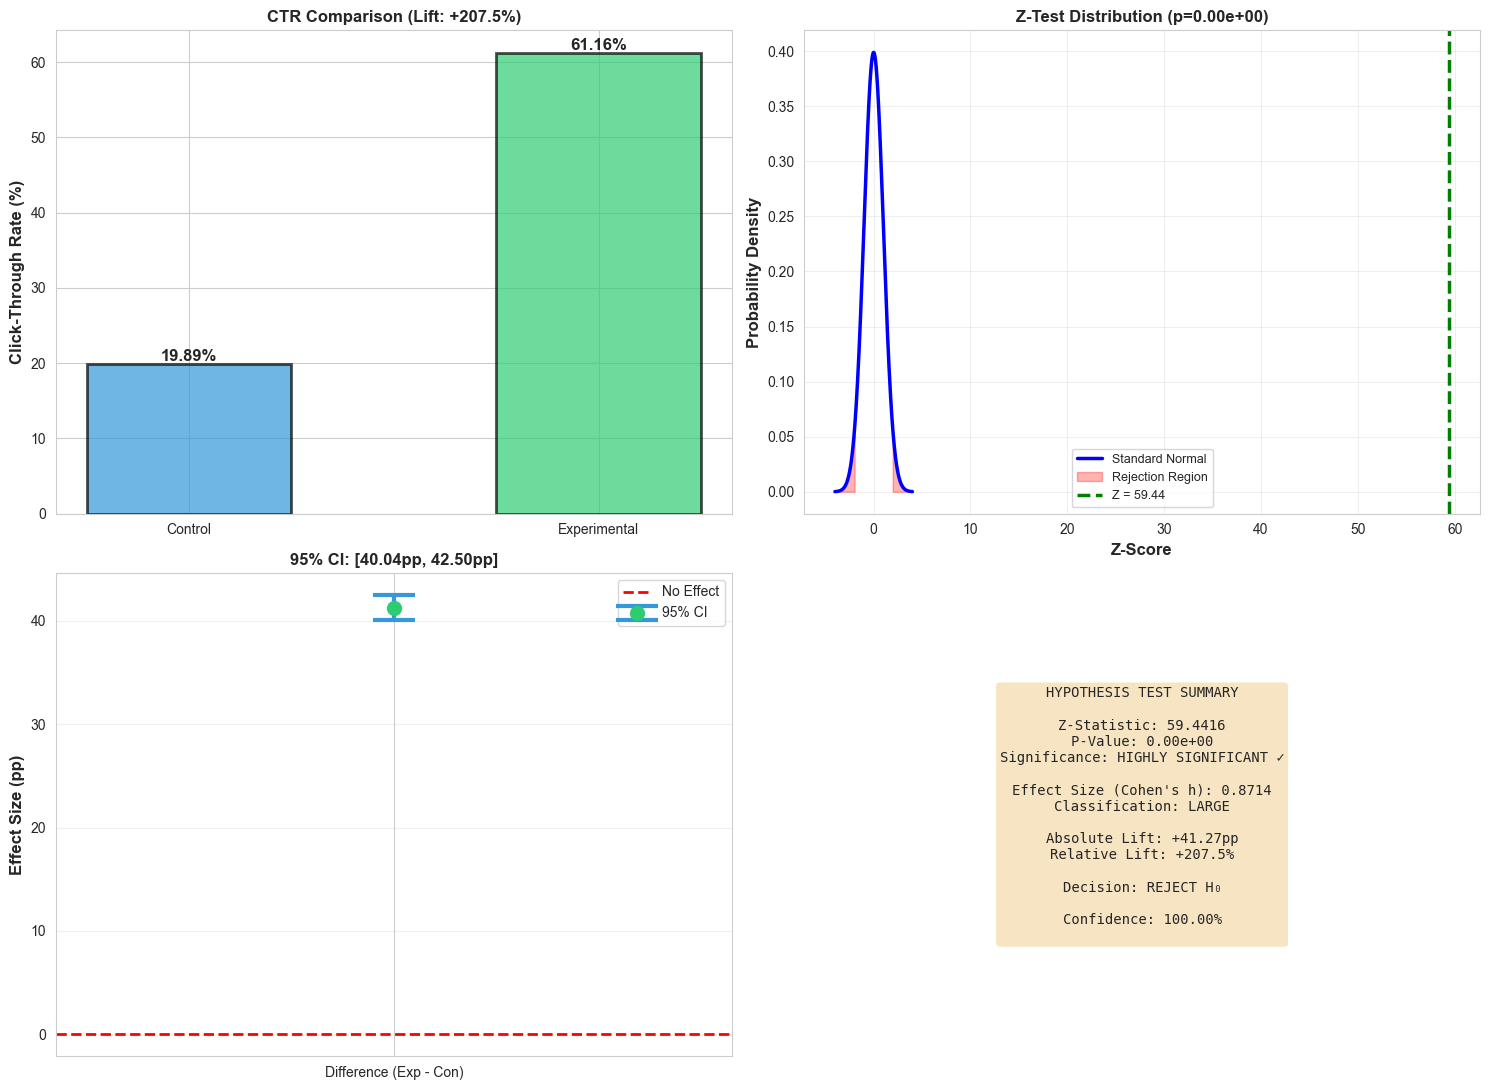

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Plot 1: CTR Comparison
ax1 = axes[0, 0]
groups = ['Control', 'Experimental']

ctr_values = [p_control * 100, p_experimental * 100]
colors = ['#3498db', '#2ecc71']
bars = ax1.bar(groups, ctr_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2, width=0.5)
ax1.set_ylabel('Click-Through Rate (%)', fontsize=12, fontweight='bold')
ax1.set_title(f'CTR Comparison (Lift: +{relative_diff:.1f}%)', fontsize=12, fontweight='bold')
for bar, value in zip(bars, ctr_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Plot 2: Normal Distribution & Z-Test
ax2 = axes[0, 1]
x_range = np.linspace(-4, 4, 1000)
ax2.plot(x_range, norm.pdf(x_range), 'b-', linewidth=2.5, label='Standard Normal')
ax2.fill_between(x_range[x_range < -1.96], norm.pdf(x_range[x_range < -1.96]), 
                 alpha=0.3, color='red', label='Rejection Region')
ax2.fill_between(x_range[x_range > 1.96], norm.pdf(x_range[x_range > 1.96]), 
                 alpha=0.3, color='red')
ax2.axvline(x=z_stat, color='green', linestyle='--', linewidth=2.5, label=f'Z = {z_stat:.2f}')
ax2.set_xlabel('Z-Score', fontsize=12, fontweight='bold')
ax2.set_ylabel('Probability Density', fontsize=12, fontweight='bold')
ax2.set_title(f'Z-Test Distribution (p={p_value:.2e})', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Plot 3: Confidence Interval
ax3 = axes[1, 0]
ax3.errorbar(1, absolute_diff*100, 
            yerr=[[absolute_diff*100 - ci_lower*100], [ci_upper*100 - absolute_diff*100]],
            fmt='o', markersize=10, linewidth=3, capsize=15, capthick=3, color='#2ecc71', 
            ecolor='#3498db', label='95% CI')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=2, label='No Effect')
ax3.set_xlim(0.5, 1.5)
ax3.set_xticks([1])
ax3.set_xticklabels(['Difference (Exp - Con)'])
ax3.set_ylabel('Effect Size (pp)', fontsize=12, fontweight='bold')
ax3.set_title(f'95% CI: [{ci_lower*100:.2f}pp, {ci_upper*100:.2f}pp]', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Plot 4: Test Summary
ax4 = axes[1, 1]
ax4.axis('off')
summary_text = f"""HYPOTHESIS TEST SUMMARY

Z-Statistic: {z_stat:.4f}
P-Value: {p_value:.2e}
Significance: {'HIGHLY SIGNIFICANT ✓' if is_significant else 'NOT SIGNIFICANT'}

Effect Size (Cohen's h): {cohens_h:.4f}
Classification: {effect_size}

Absolute Lift: +{absolute_diff*100:.2f}pp
Relative Lift: +{relative_diff:.1f}%

Decision: {'REJECT H₀' if is_significant else 'FAIL TO REJECT'}

Confidence: {(1-p_value)*100:.2f}%
"""
ax4.text(0.5, 0.5, summary_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8), family='monospace')

plt.tight_layout()
plt.savefig('lunar_statistical_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: lunar_statistical_analysis.png")
plt.show()






### 7: Save Result

In [10]:
print("\n[SECTION 7] SAVING TEST RESULTS")
print("-" * 80)

# Create results dataframe
results_data = {
    'Test_Parameter': [
        'Control CTR (%)',
        'Experimental CTR (%)',
        'Absolute Lift (pp)',
        'Relative Lift (%)',
        'Z-Statistic',
        'P-Value',
        'Is Significant',
        'Cohen h',
        'CI Lower (pp)',
        'CI Upper (pp)'
    ],
    'Value': [
        f'{p_control*100:.4f}',
        f'{p_experimental*100:.4f}',
        f'{absolute_diff*100:.4f}',
        f'{relative_diff:.2f}',
        f'{z_stat:.4f}',
        f'{p_value:.10f}',
        'YES' if is_significant else 'NO',
        f'{cohens_h:.4f}',
        f'{ci_lower*100:.4f}',
        f'{ci_upper*100:.4f}'
    ]
}

results_df = pd.DataFrame(results_data)
results_df.to_csv('lunar_statistical_results.csv', index=False)
print("✓ Saved: lunar_statistical_results.csv")
print("\n✓ NOTEBOOK 3 COMPLETE - HYPOTHESIS TESTING FINISHED")


[SECTION 7] SAVING TEST RESULTS
--------------------------------------------------------------------------------
✓ Saved: lunar_statistical_results.csv

✓ NOTEBOOK 3 COMPLETE - HYPOTHESIS TESTING FINISHED
